# Modeling

Este notebook tem como objetivo treinar, avaliar e comparar diferentes algoritmos de Machine Learning para previsão de inadimplência, utilizando as bases e artefatos construídos nas etapas anteriores do projeto.

Ao longo do desenvolvimento foram realizadas etapas de definição da população, construção da variável alvo, análise exploratória dos dados, tratamento de variáveis, engenharia de atributos e seleção de variáveis. Com isso, as bases utilizadas nesta etapa já se encontram preparadas para o treinamento dos modelos.

Serão avaliados três algoritmos amplamente utilizados em problemas de classificação e risco de crédito:

* Regressão Logística;
* Random Forest;
* LightGBM.

A avaliação será realizada utilizando validação cruzada estratificada no conjunto de treinamento balanceado, além de validações independentes nas bases OOS (*Out of Sample*) e OOT (*Out of Time*), permitindo medir tanto a capacidade preditiva quanto a estabilidade temporal dos modelos.

As métricas utilizadas ao longo da análise serão:

* **AUC (Area Under the Curve)**: mede a capacidade de discriminação entre bons e maus pagadores;
* **KS (Kolmogorov-Smirnov)**: mede a separação máxima entre as distribuições dos grupos;
* **Gini**: métrica derivada da AUC amplamente utilizada em modelagem de crédito;
* **PSI (Population Stability Index)**: avalia a estabilidade da distribuição dos scores entre diferentes populações.

Além das métricas numéricas, serão analisadas visualizações como Curva ROC e Distribuição dos Scores, permitindo uma interpretação mais intuitiva do comportamento dos modelos.

Ao final do notebook será selecionado o modelo com melhor equilíbrio entre desempenho, estabilidade e capacidade de generalização, resultando no modelo final de previsão de inadimplência deste projeto.

## 1. Imports e Configurações

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import os
import pickle
import warnings

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from src.modeling import *

warnings.filterwarnings("ignore")

## 2. Dicionário de Tipos

In [2]:
with open(
    r"../outputs/dicts/tipos_var.pkl",
    "rb"
) as f:

    tipos_var = pickle.load(f)

display(tipos_var)

{'key': ['id_cliente', 'safra_mes'],
 'binary': ['possui_carro', 'possui_imovel', 'sexo_masculino'],
 'categorical': [],
 'integer': ['qtd_filhos',
  'qtd_membros_familia',
  'qtd_contratos_aceitos_historico',
  'qtd_contratos_recusados_historico',
  'nota_regiao_cliente',
  'nota_regiao_cliente_cidade',
  'idade'],
 'numeric': ['valor_bem_submissao',
  'media_valor_credito_aceito_historico',
  'soma_valor_credito_ativo_historico',
  'valor_credito_submissao',
  'valor_parcela_submissao',
  'renda_anual',
  'tipo_contrato_submissao_woe',
  'dia_semana_solicitacao_submissao_woe',
  'hora_solicitacao_submissao_woe',
  'estado_civil_woe',
  'tipo_renda_woe',
  'tipo_organizacao_woe',
  'tipo_moradia_woe',
  'nivel_educacao_woe'],
 'datetime': [],
 'target': 'target'}

## 3. Carregamento das Bases e Artefatos

In [3]:
train_model = pd.read_parquet("../data/processed/train_model.parquet")
train_rus_model = pd.read_parquet("../data/processed/train_rus_model.parquet")
oos_model = pd.read_parquet("../data/processed/oos_model.parquet")
oot_model = pd.read_parquet("../data/processed/oot_model.parquet")

print(train_model.shape)
print(train_rus_model.shape)
print(oos_model.shape)
print(oot_model.shape)

(49529, 27)
(814, 27)
(12383, 27)
(19970, 27)


In [4]:
with open(
    "../outputs/dicts/features_corr.pkl",
    "rb"
) as f:

    features_corr = pickle.load(f)

## 4. Separação de Features

In [5]:
features_linear = features_corr
features_tree = (
    tipos_var["binary"]
    + tipos_var["integer"]
    + tipos_var["numeric"]
)

print(f"Nº de variáveis lineares: {len(features_linear)}")
print(f"Nº de variáveis de árvore: {len(features_tree)}")

Nº de variáveis lineares: 14
Nº de variáveis de árvore: 24


## 5. Modelagem

Nesta etapa serão treinados diferentes algoritmos de classificação com o objetivo de prever a probabilidade de inadimplência dos clientes.

Conforme definido nas etapas anteriores, foram construídos dois conjuntos de variáveis:

* **Modelos lineares:** utilizam apenas as variáveis aprovadas após as análises de multicolinearidade (VIF) e correlação, reduzindo redundâncias e favorecendo a interpretabilidade do modelo.
* **Modelos não lineares:** utilizam todas as variáveis disponíveis após o processo de Feature Engineering, uma vez que algoritmos baseados em árvores são naturalmente mais robustos à presença de correlação entre variáveis.

Todos os modelos serão avaliados utilizando validação cruzada estratificada no conjunto de treinamento balanceado (RUS), garantindo uma estimativa mais robusta do desempenho durante o desenvolvimento.

Posteriormente, os modelos serão avaliados nas bases OOS (Out of Sample) e OOT (Out of Time), permitindo verificar sua capacidade de generalização e estabilidade temporal.

In [6]:
X_train = train_rus_model[
    features_linear
]

y_train = train_rus_model[
    TARGET
]

X_oos = oos_model[
    features_linear
]

y_oos = oos_model[
    TARGET
]

X_oot = oot_model[
    features_linear
]

y_oot = oot_model[
    TARGET
]

### 5.1 Regressão Logística

A Regressão Logística é um dos modelos mais utilizados em risco de crédito devido à sua simplicidade, interpretabilidade e facilidade de governança.

O modelo estima a probabilidade de ocorrência de um evento binário através da função logística.

$$
P(Y=1)=\frac{1}{1+e^{-(\beta_0+\beta_1X_1+\cdots+\beta_nX_n)}}
$$

Onde:

* (P(Y=1)) representa a probabilidade de inadimplência;
* (\beta_0) representa o intercepto;
* (\beta_i) representam os coeficientes estimados;
* (X_i) representam as variáveis explicativas.

**Parâmetros Utilizados**

| Parâmetro       | Descrição                                       |
| --------------- | ----------------------------------------------- |
| random_state=42 | Garante reprodutibilidade                       |
| max_iter=5000   | Aumenta o limite de iterações para convergência |

A principal vantagem deste modelo é sua alta interpretabilidade, permitindo compreender o impacto individual de cada variável na probabilidade de inadimplência.


In [7]:
lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=5000
)

lr_model, lr_results, lr_scores = (
    train_and_evaluate_model(
        model=lr,
        X_train=X_train,
        y_train=y_train,
        X_oos=X_oos,
        y_oos=y_oos,
        X_oot=X_oot,
        y_oot=y_oot
    )
)

oos_score_lr = lr_scores["oos_score"]
oot_score_lr = lr_scores["oot_score"]

display(lr_results)

{'cv': {'AUC': 0.6155062813539472,
  'KS': np.float64(0.1769041769041769),
  'Gini': 0.2310125627078945},
 'oos': {'AUC': 0.6198727190574952,
  'KS': np.float64(0.22864188424331547),
  'Gini': 0.23974543811499038,
  'PSI': 0.02552056652942305},
 'oot': {'AUC': 0.5775157254189269,
  'KS': np.float64(0.29155222752096344),
  'Gini': 0.15503145083785386,
  'PSI': 0.17367833715876296}}

### 5.2 Random Forest

Random Forest é um algoritmo baseado em um conjunto de árvores de decisão treinadas de forma independente.

Cada árvore é construída utilizando uma amostra aleatória dos registros e das variáveis disponíveis. A predição final é obtida através da agregação dos resultados de todas as árvores.

Principais características:

* Captura relações não lineares;
* Possui baixa sensibilidade a outliers;
* Tolera variáveis correlacionadas;
* Fornece medidas de importância das variáveis.

**Parâmetros Utilizados**

| Parâmetro        | Descrição                                  |
| ---------------- | ------------------------------------------ |
| n_estimators=500 | Quantidade de árvores                      |
| random_state=42  | Reprodutibilidade                          |
| n_jobs=-1        | Utilização de todos os núcleos disponíveis |

Este modelo costuma apresentar boa capacidade preditiva, porém com menor interpretabilidade quando comparado à Regressão Logística.

In [8]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model, rf_results, rf_scores = (
    train_and_evaluate_model(
        model=rf,
        X_train=train_rus_model[features_tree],
        y_train=train_rus_model[TARGET],
        X_oos=oos_model[features_tree],
        y_oos=oos_model[TARGET],
        X_oot=oot_model[features_tree],
        y_oot=oot_model[TARGET]
    )
)

oos_score_rf = rf_scores["oos_score"]
oot_score_rf = rf_scores["oot_score"]

display(rf_results)

{'cv': {'AUC': 0.5628950370965113,
  'KS': np.float64(0.09336609336609336),
  'Gini': 0.12579007419302268},
 'oos': {'AUC': 0.5806741962317049,
  'KS': np.float64(0.16520577777564904),
  'Gini': 0.16134839246340982,
  'PSI': 0.05720288216134241},
 'oot': {'AUC': 0.6360652974962309,
  'KS': np.float64(0.26883292567946104),
  'Gini': 0.2721305949924617,
  'PSI': 0.22598236843509162}}


### 5.3 LightGBM

LightGBM (Light Gradient Boosting Machine) é um algoritmo de Gradient Boosting baseado em árvores de decisão.

Diferentemente do Random Forest, as árvores são construídas sequencialmente, onde cada nova árvore busca corrigir os erros cometidos pelas árvores anteriores.

Principais características:

* Excelente desempenho preditivo;
* Treinamento eficiente;
* Capacidade de modelar relações complexas;
* Muito utilizado em competições e aplicações de machine learning.

**Parâmetros Utilizados**

| Parâmetro          | Descrição                |
| ------------------ | ------------------------ |
| n_estimators=500   | Número máximo de árvores |
| learning_rate=0.05 | Taxa de aprendizado      |
| random_state=42    | Reprodutibilidade        |

Embora apresente elevada capacidade preditiva, este modelo possui menor interpretabilidade quando comparado à Regressão Logística.

In [9]:
lgbm = LGBMClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    max_depth=4,
    verbosity=-1
)

lgbm_model, lgbm_results, lgbm_scores = (
    train_and_evaluate_model(
        model=lgbm,
        X_train=train_rus_model[features_tree],
        y_train=train_rus_model[TARGET],
        X_oos=oos_model[features_tree],
        y_oos=oos_model[TARGET],
        X_oot=oot_model[features_tree],
        y_oot=oot_model[TARGET]
    )
)

oos_score_lgbm = lgbm_scores["oos_score"]
oot_score_lgbm = lgbm_scores["oot_score"]

display(lgbm_results)

{'cv': {'AUC': 0.6043863832561621,
  'KS': np.float64(0.16707616707616707),
  'Gini': 0.20877276651232424},
 'oos': {'AUC': 0.563344301974515,
  'KS': np.float64(0.12795949745422142),
  'Gini': 0.12668860394903003,
  'PSI': 0.04316288298593688},
 'oot': {'AUC': 0.6210732000601233,
  'KS': np.float64(0.3316116220069324),
  'Gini': 0.24214640012024669,
  'PSI': 0.15537681752167898}}

## 6. Comparação entre Modelos

Após o treinamento, os modelos serão comparados utilizando métricas de desempenho e estabilidade.

A seleção do melhor modelo não será baseada exclusivamente em desempenho preditivo, mas também em sua capacidade de generalização e estabilidade temporal.

A ordem de priorização adotada será:

1. Melhor desempenho na base OOT;
2. Melhor capacidade discriminatória (AUC, KS e Gini);
3. Menor degradação entre Train, OOS e OOT;
4. Melhor estabilidade (PSI);
5. Maior interpretabilidade em caso de desempenhos semelhantes.

Essa abordagem busca reproduzir práticas amplamente utilizadas em projetos de modelagem de risco de crédito.


### 6.1 Métricas de Desempenho

- **AUC (Area Under the Curve):**

A AUC mede a capacidade do modelo em separar bons e maus pagadores.

Valores possíveis:

| AUC         | Interpretação     |
| ----------- | ----------------- |
| 0.50        | Sem discriminação |
| 0.60 - 0.70 | Fraco             |
| 0.70 - 0.80 | Bom               |
| 0.80 - 0.90 | Muito Bom         |
| > 0.90      | Excelente         |

Quanto maior, melhor.

- **KS (Kolmogorov-Smirnov):**

O KS mede a distância máxima entre as distribuições acumuladas dos bons e maus pagadores.

Valores de referência:

| KS          | Interpretação |
| ----------- | ------------- |
| < 0.20      | Fraco         |
| 0.20 - 0.40 | Bom           |
| 0.40 - 0.60 | Muito Bom     |
| > 0.60      | Excelente     |

Quanto maior, melhor.

- **Gini:**

O coeficiente de Gini é derivado diretamente da AUC.

Gini=2\times AUC-1

Valores possíveis:

| Gini        | Interpretação     |
| ----------- | ----------------- |
| 0           | Sem discriminação |
| 0.20 - 0.40 | Bom               |
| 0.40 - 0.60 | Muito Bom         |
| > 0.60      | Excelente         |

Quanto maior, melhor.

- **PSI (Population Stability Index):**

O PSI mede a estabilidade da distribuição dos scores entre diferentes bases.

É utilizado para identificar possíveis mudanças de comportamento da população ao longo do tempo.

Valores de referência:

| PSI         | Interpretação |
| ----------- | ------------- |
| < 0.10      | Estável       |
| 0.10 - 0.25 | Atenção       |
| > 0.25      | Instável      |

Quanto menor, melhor.

In [10]:
comparison = pd.DataFrame([
    {
        "Modelo": "Logistic Regression",
        **lr_results["oot"]
    },
    {
        "Modelo": "Random Forest",
        **rf_results["oot"]
    },
    {
        "Modelo": "LightGBM",
        **lgbm_results["oot"]
    }
])

display(comparison)

,Modelo,AUC,KS,Gini,PSI
0,Logistic Regression,0.577516,0.291552,0.155031,0.173678
1,Random Forest,0.636065,0.268833,0.272131,0.225982
2,LightGBM,0.621073,0.331612,0.242146,0.155377


### 6.2 Curva ROC

A Curva ROC (Receiver Operating Characteristic) representa a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos para diferentes pontos de corte.

A área sob essa curva corresponde à AUC.

Quanto mais próxima a curva estiver do canto superior esquerdo do gráfico, melhor será a capacidade de separação entre clientes adimplentes e inadimplentes.

Curvas próximas da diagonal indicam baixo poder discriminatório.

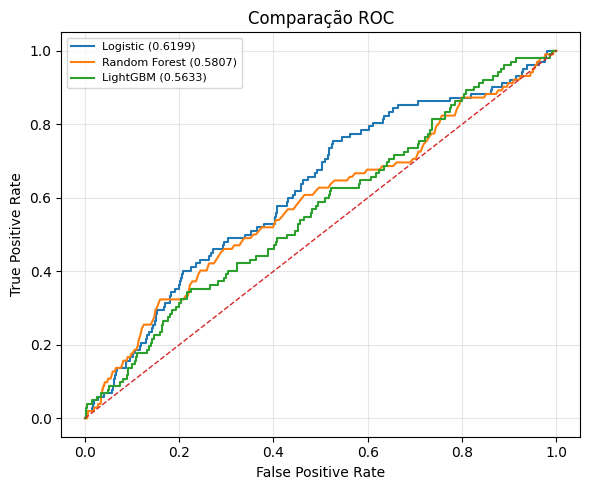

In [11]:
plot_roc_comparison(
    oos_model[TARGET],
    {
        "Logistic": oos_score_lr,
        "Random Forest": oos_score_rf,
        "LightGBM": oos_score_lgbm
    }
)

### 6.3 Distribuição de Classes

Além das métricas tradicionais, será analisada a distribuição dos scores para bons e maus pagadores.

O objetivo é verificar visualmente a capacidade do modelo em separar os grupos.

O comportamento esperado é:

* Clientes adimplentes (Good) concentrados em faixas baixas de score;
* Clientes inadimplentes (Bad) concentrados em faixas altas de score;
* Menor sobreposição possível entre as distribuições.

Quanto maior a separação entre as distribuições, melhor tende a ser a capacidade discriminatória do modelo.

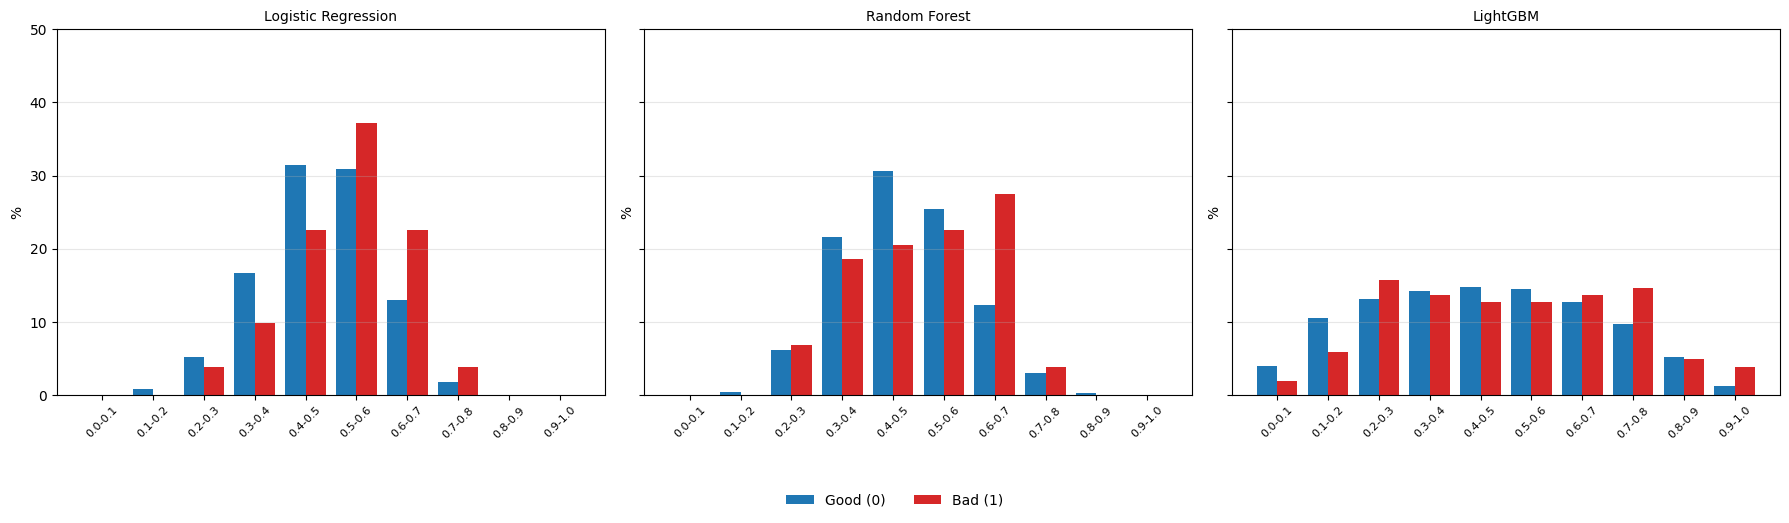

In [14]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True
)

plot_score_distribution(
    oos_model[TARGET],
    oos_score_lr,
    "Logistic Regression",
    axes[0]
)

plot_score_distribution(
    oos_model[TARGET],
    oos_score_rf,
    "Random Forest",
    axes[1]
)

plot_score_distribution(
    oos_model[TARGET],
    oos_score_lgbm,
    "LightGBM",
    axes[2]
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False,
    fontsize=10
)

plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)

plt.show()

## 7. Modelo Selecionado

A seleção do modelo final foi realizada utilizando como principal critério o **KS (Kolmogorov-Smirnov) na base OOT (Out of Time)**.

O KS é uma das métricas mais utilizadas em modelagem de risco de crédito, pois mede a capacidade do modelo em separar clientes adimplentes e inadimplentes. Quanto maior o valor do KS, maior é a distância entre as distribuições dos dois grupos e, consequentemente, melhor é o poder discriminatório do modelo.

A escolha da base OOT como referência busca priorizar modelos com maior capacidade de generalização temporal, simulando um cenário mais próximo da utilização em produção.

A ordem de priorização adotada foi:

1. Maior KS na base OOT;
2. Maior AUC na base OOT;
3. Maior Gini na base OOT;
4. Menor PSI;
5. Maior interpretabilidade em caso de desempenhos semelhantes.

O modelo selecionado foi salvo juntamente com o conjunto de variáveis utilizado em seu treinamento, garantindo a reprodutibilidade completa do processo de modelagem.

**Justificativa**

Em projetos de risco de crédito, o KS é amplamente utilizado como principal métrica de comparação entre modelos por representar diretamente a capacidade de separação entre bons e maus pagadores.

Enquanto métricas como AUC e Gini avaliam a qualidade global do ranking gerado pelo modelo, o KS identifica o ponto de maior distinção entre as distribuições dos grupos, sendo especialmente útil para análises de concessão de crédito, definição de políticas de aprovação e construção de scorecards.

Dessa forma, foi adotado como principal critério de seleção neste projeto.


In [17]:
model_results = {
    "Logistic Regression": {
        "model": lr_model,
        "results": lr_results
    },
    "Random Forest": {
        "model": rf_model,
        "results": rf_results
    },
    "LightGBM": {
        "model": lgbm_model,
        "results": lgbm_results
    }
}

ranking = pd.DataFrame([
    {
        "Modelo": name,
        "AUC_OOT": info["results"]["oot"]["AUC"],
        "KS_OOT": info["results"]["oot"]["KS"],
        "Gini_OOT": info["results"]["oot"]["Gini"],
        "PSI_OOT": info["results"]["oot"]["PSI"]
    }
    for name, info in model_results.items()
])

ranking = ranking.sort_values(
    "KS_OOT",
    ascending=False
).reset_index(drop=True)

ranking

,Modelo,AUC_OOT,KS_OOT,Gini_OOT,PSI_OOT
0,LightGBM,0.621073,0.331612,0.242146,0.155377
1,Logistic Regression,0.577516,0.291552,0.155031,0.173678
2,Random Forest,0.636065,0.268833,0.272131,0.225982


In [18]:
best_model_name = ranking.iloc[0]["Modelo"]

best_model = model_results[
    best_model_name
]["model"]

print(
    f"Modelo Selecionado: {best_model_name}"
)

Modelo Selecionado: LightGBM


In [ ]:
os.makedirs(
    "outputs/models",
    exist_ok=True
)

with open(
    "outputs/models/best_model.pkl",
    "wb"
) as f:

    pickle.dump(
        best_model,
        f
    )

if best_model_name == "Logistic Regression":

    selected_features = features_linear

else:

    selected_features = features_tree

## 8. Conclusão

Neste projeto foi desenvolvida uma pipeline completa de modelagem de risco de crédito, contemplando todas as etapas necessárias para construção de um modelo preditivo de inadimplência: definição da população de estudo, construção da variável alvo, análise exploratória dos dados, tratamento e transformação de variáveis, engenharia de atributos, seleção de variáveis e modelagem.

Durante o processo de preparação dos dados foram aplicadas técnicas amplamente utilizadas no mercado financeiro, incluindo tratamento de valores ausentes, controle de valores fora de domínio, transformação de variáveis categóricas por Weight of Evidence (WOE), normalização, análise de multicolinearidade por VIF e redução de redundância por correlação. Essas etapas permitiram construir uma base consistente e adequada para o treinamento dos modelos.

Na etapa de modelagem foram avaliados três algoritmos distintos: Regressão Logística, Random Forest e LightGBM. A comparação foi realizada utilizando validação cruzada estratificada no conjunto de treinamento balanceado, além de validações independentes nas bases OOS (*Out of Sample*) e OOT (*Out of Time*), permitindo analisar tanto o desempenho preditivo quanto a capacidade de generalização dos modelos.

As avaliações foram conduzidas por meio das métricas AUC, KS, Gini e PSI, complementadas por análises visuais através das Curvas ROC e da distribuição dos scores para bons e maus pagadores. Essa abordagem permitiu avaliar não apenas a qualidade das previsões, mas também a estabilidade e robustez dos modelos em diferentes cenários.

Ao final do processo, o **LightGBM** apresentou o melhor desempenho entre os modelos avaliados, obtendo o maior poder discriminatório na base OOT e demonstrando maior capacidade de separação entre clientes adimplentes e inadimplentes. Os resultados indicam que o algoritmo foi capaz de capturar relações mais complexas entre as variáveis, superando os modelos concorrentes sem comprometer sua capacidade de generalização.

Dessa forma, o LightGBM foi selecionado como modelo final deste projeto, representando a alternativa com melhor equilíbrio entre desempenho, estabilidade e potencial de aplicação em um ambiente real de concessão de crédito.

A solução desenvolvida demonstra uma abordagem estruturada e alinhada às boas práticas de modelagem de risco, fornecendo uma base sólida para futuras evoluções, como otimização de hiperparâmetros, interpretação avançada por SHAP Values, monitoramento contínuo do modelo e implantação em ambiente produtivo.
